# **1.PREPROCESSING DATA**


In [3]:
import pandas as pd
import numpy as np


df = pd.read_csv('student_performance_finalscore.csv')

display(df.head())

,Student_ID,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score
0,STU00001,17,Female,8.20,80.0,7.3,2.3,3.2,3.07,No,Online,Average,Average,Yes,3,High,1.8,87.10
1,STU00002,22,Male,4.07,69.2,7.9,3.6,0.5,2.66,Yes,Offline,Average,Good,No,2,Middle,1.0,92.03
2,STU00003,23,Female,5.07,74.2,6.7,2.6,4.7,3.27,No,Hybrid,Average,Good,No,1,Middle,4.2,95.37
3,STU00004,22,Female,5.82,82.5,3.7,3.3,2.3,2.87,No,Offline,Average,Excellent,No,0,Middle,3.6,90.73
4,STU00005,21,Male,3.42,90.8,7.4,7.0,3.1,2.82,Yes,Offline,Average,Good,No,2,Middle,4.5,74.71


In [4]:

print("Dimensi Dataset")

print(f"Jumlah baris  : {df.shape[0]}")
print(f"Jumlah kolom  : {df.shape[1]}")

Dimensi Dataset
Jumlah baris  : 8000
Jumlah kolom  : 18


In [5]:
print("Nama Kolom")

print(df.columns.tolist())

Nama Kolom
['Student_ID', 'Age', 'Gender', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Stress_Level', 'Screen_Time', 'Previous_GPA', 'Part_Time_Job', 'Study_Method', 'Diet_Quality', 'Internet_Quality', 'Extracurricular', 'Tutoring_Sessions_Per_Week', 'Family_Income_Level', 'Exam_Anxiety_Score', 'Final_Score']


In [6]:
print("Informasi Dataset")

df.info()

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  8000 non-null   object 
 1   Age                         8000 non-null   int64  
 2   Gender                      8000 non-null   object 
 3   Hours_Studied               8000 non-null   float64
 4   Attendance                  8000 non-null   float64
 5   Sleep_Hours                 8000 non-null   float64
 6   Stress_Level                8000 non-null   float64
 7   Screen_Time                 8000 non-null   float64
 8   Previous_GPA                8000 non-null   float64
 9   Part_Time_Job               8000 non-null   object 
 10  Study_Method                8000 non-null   object 
 11  Diet_Quality                8000 non-null   object 
 12  Internet_Quality            8000 non-null   object 
 13  Extracurricular

In [7]:
print("Jumlah Missing Values")
print(df.isnull().sum())

Jumlah Missing Values
Student_ID                    0
Age                           0
Gender                        0
Hours_Studied                 0
Attendance                    0
Sleep_Hours                   0
Stress_Level                  0
Screen_Time                   0
Previous_GPA                  0
Part_Time_Job                 0
Study_Method                  0
Diet_Quality                  0
Internet_Quality              0
Extracurricular               0
Tutoring_Sessions_Per_Week    0
Family_Income_Level           0
Exam_Anxiety_Score            0
Final_Score                   0
dtype: int64


In [8]:
print("Jumlah Data Duplikat")
print(df.duplicated().sum())

Jumlah Data Duplikat
0


In [9]:
df_raw = df.copy()

In [10]:
if 'Student_ID' in df.columns:
    df.drop(columns=['Student_ID'], inplace=True)

print("\n" + "=" * 60)
print("Kolom Setelah Menghapus Student_ID")
print("=" * 60)
print(df.columns.tolist())



Kolom Setelah Menghapus Student_ID
['Age', 'Gender', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Stress_Level', 'Screen_Time', 'Previous_GPA', 'Part_Time_Job', 'Study_Method', 'Diet_Quality', 'Internet_Quality', 'Extracurricular', 'Tutoring_Sessions_Per_Week', 'Family_Income_Level', 'Exam_Anxiety_Score', 'Final_Score']


In [11]:
print("IDENTIFIKASI KOLOM KATEGORIKAL")
print("=" * 60)

df_features = df.drop(columns=['Final_Score'])

# Mendeteksi kolom kategorikal
categorical_cols = df_features.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print("Kolom kategorikal yang terdeteksi:")
print(categorical_cols)

print(f"\nJumlah kolom kategorikal: {len(categorical_cols)}")

cat_cols = df.select_dtypes(include=['object', 'bool']).columns

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

print(cat_cols)
print(df_encoded.head())
# print(df.dtypes)

IDENTIFIKASI KOLOM KATEGORIKAL
Kolom kategorikal yang terdeteksi:
['Gender', 'Part_Time_Job', 'Study_Method', 'Diet_Quality', 'Internet_Quality', 'Extracurricular', 'Family_Income_Level']

Jumlah kolom kategorikal: 7
Index(['Gender', 'Part_Time_Job', 'Study_Method', 'Diet_Quality',
       'Internet_Quality', 'Extracurricular', 'Family_Income_Level'],
      dtype='object')
   Age  Hours_Studied  ...  Family_Income_Level_Low  Family_Income_Level_Middle
0   17           8.20  ...                        0                           0
1   22           4.07  ...                        0                           1
2   23           5.07  ...                        0                           1
3   22           5.82  ...                        0                           1
4   21           3.42  ...                        0                           1

[5 rows x 23 columns]


In [12]:
print(df_encoded.columns)

Index(['Age', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Stress_Level',
       'Screen_Time', 'Previous_GPA', 'Tutoring_Sessions_Per_Week',
       'Exam_Anxiety_Score', 'Final_Score', 'Gender_Male', 'Gender_Non-Binary',
       'Part_Time_Job_Yes', 'Study_Method_Offline', 'Study_Method_Online',
       'Diet_Quality_Good', 'Diet_Quality_Poor', 'Internet_Quality_Excellent',
       'Internet_Quality_Good', 'Internet_Quality_Poor', 'Extracurricular_Yes',
       'Family_Income_Level_Low', 'Family_Income_Level_Middle'],
      dtype='object')


In [13]:
X = df_encoded.drop("Final_Score", axis=1)
y = df_encoded["Final_Score"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6400, 22)
X_test shape: (1600, 22)
y_train shape: (6400,)
y_test shape: (1600,)


# **2. EDA**

| Cell | Nama Analisis                                 | Status    |
| ---- | --------------------------------------------- | --------- |
| 1    | Import Library untuk EDA                      | ✅ Success |
| 2    | Menentukan Kolom Numerik                      | ✅ Success |
| 3    | Statistik Deskriptif                          | ✅ Success |
| 4    | Distribusi Target `Final_Score`               | ✅ Success |
| 5    | Distribusi Semua Fitur Numerik                | ✅ Success |
| 6    | Boxplot Semua Fitur Numerik (Deteksi Outlier) | ✅ Success |
| 7    | Correlation Matrix                            | ✅ Success |
| 8    | Heatmap Korelasi                              | ✅ Success |
| 9    | Korelasi Fitur terhadap `Final_Score`         | ✅ Success |
| 10   | Top 10 Features yang Paling Berkorelasi       | ✅ Success |
| 11   | Scatter Plot Fitur Penting vs `Final_Score`   | ✅ Success |
| 12   | Analisis Fitur Kategorikal                    | ✅ Success |
| 13   | Pairplot (Opsional)                           | ✅ Success |
| 14   | Insight Summary Otomatis                      | ✅ Success |


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [17]:
numerical_cols = df_encoded.drop(columns=['Final_Score']).select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print('Kolom numerik:')
print(numerical_cols)
print(f'Jumlah kolom numerik: {len(numerical_cols)}')

Kolom numerik:
['Age', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Stress_Level', 'Screen_Time', 'Previous_GPA', 'Tutoring_Sessions_Per_Week', 'Exam_Anxiety_Score', 'Gender_Male', 'Gender_Non-Binary', 'Part_Time_Job_Yes', 'Study_Method_Offline', 'Study_Method_Online', 'Diet_Quality_Good', 'Diet_Quality_Poor', 'Internet_Quality_Excellent', 'Internet_Quality_Good', 'Internet_Quality_Poor', 'Extracurricular_Yes', 'Family_Income_Level_Low', 'Family_Income_Level_Middle']
Jumlah kolom numerik: 22


In [18]:
print('=' * 60)
print('STATISTIK DESKRIPTIF')
print('=' * 60)
display(df_encoded.describe())

STATISTIK DESKRIPTIF


,Age,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Tutoring_Sessions_Per_Week,Exam_Anxiety_Score,Final_Score,Gender_Male,Gender_Non-Binary,Part_Time_Job_Yes,Study_Method_Offline,Study_Method_Online,Diet_Quality_Good,Diet_Quality_Poor,Internet_Quality_Excellent,Internet_Quality_Good,Internet_Quality_Poor,Extracurricular_Yes,Family_Income_Level_Low,Family_Income_Level_Middle
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000
mean,20.494375,4.983845,79.933375,6.989125,5.014175,4.024525,2.992408,1.700625,4.494238,83.205649,0.488250,0.035500,0.399625,0.396250,0.307500,0.249250,0.25325,0.203625,0.408250,0.102500,0.452375,0.256000,0.48900
std,2.285962,1.951715,9.656594,1.192898,1.940126,1.481908,0.489530,1.112836,1.685571,12.756728,0.499893,0.185051,0.489852,0.489148,0.461487,0.432606,0.43490,0.402718,0.491541,0.303324,0.497758,0.436449,0.49991
min,17.000000,0.020000,43.300000,3.000000,1.000000,0.500000,1.500000,0.000000,1.000000,22.810000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,18.000000,3.680000,73.400000,6.200000,3.700000,3.000000,2.670000,1.000000,3.300000,75.507500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,20.500000,4.980000,80.100000,7.000000,5.000000,4.000000,2.990000,2.000000,4.400000,86.510000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,22.000000,6.312500,86.600000,7.800000,6.300000,5.000000,3.330000,2.000000,5.600000,93.080000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.00000,0.000000,1.000000,0.000000,1.000000,1.000000,1.00000
max,24.000000,12.000000,100.000000,10.000000,10.000000,9.600000,6.700000,5.000000,10.000000,99.980000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


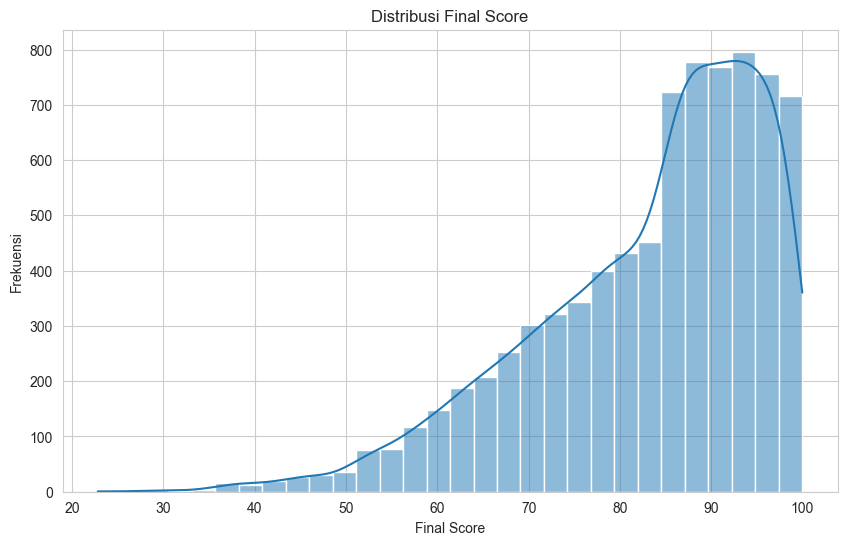

Mean Final Score   : 83.21
Median Final Score : 86.51
Std Dev            : 12.76
Minimum            : 22.81
Maximum            : 99.98


In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df_encoded['Final_Score'], bins=30, kde=True)
plt.title('Distribusi Final Score')
plt.xlabel('Final Score')
plt.ylabel('Frekuensi')
plt.show()

print(f"Mean Final Score   : {df_encoded['Final_Score'].mean():.2f}")
print(f"Median Final Score : {df_encoded['Final_Score'].median():.2f}")
print(f"Std Dev            : {df_encoded['Final_Score'].std():.2f}")
print(f"Minimum            : {df_encoded['Final_Score'].min():.2f}")
print(f"Maximum            : {df_encoded['Final_Score'].max():.2f}")

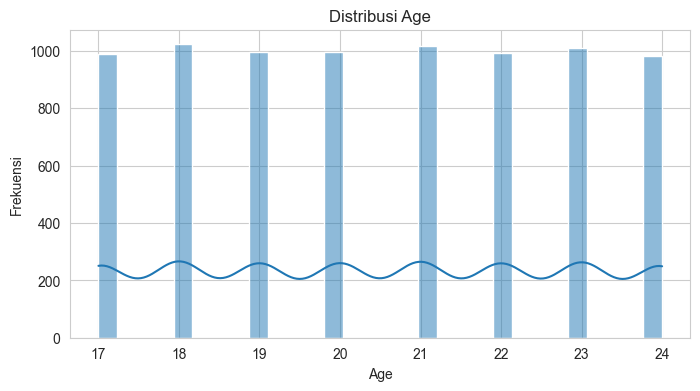

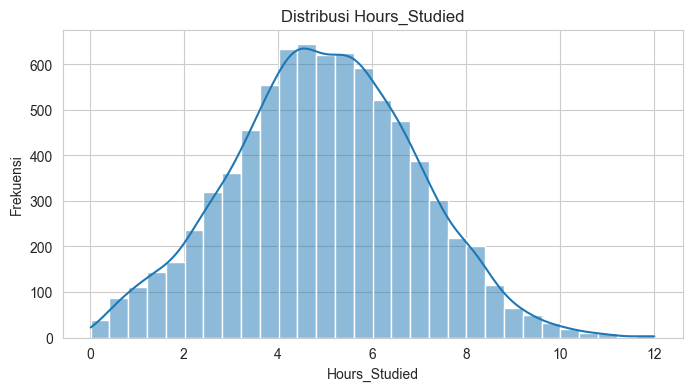

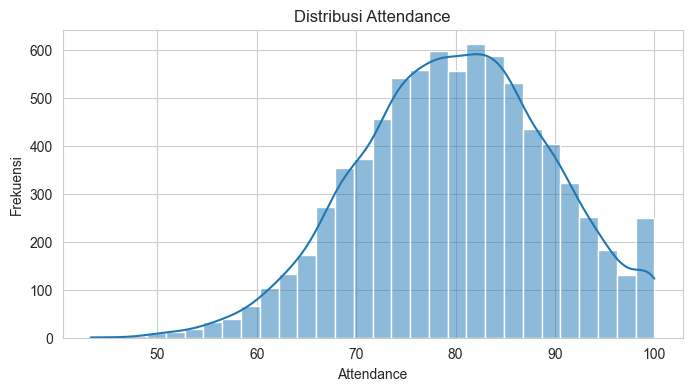

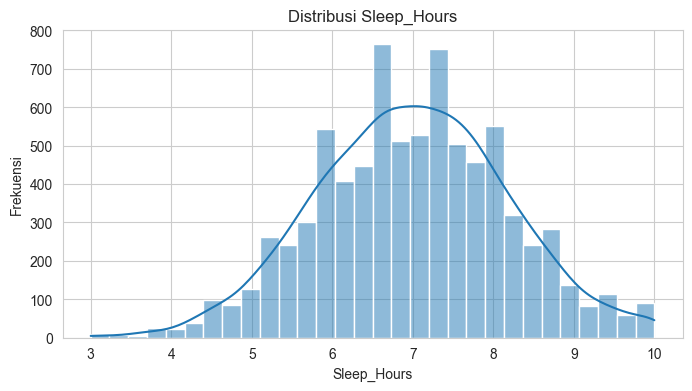

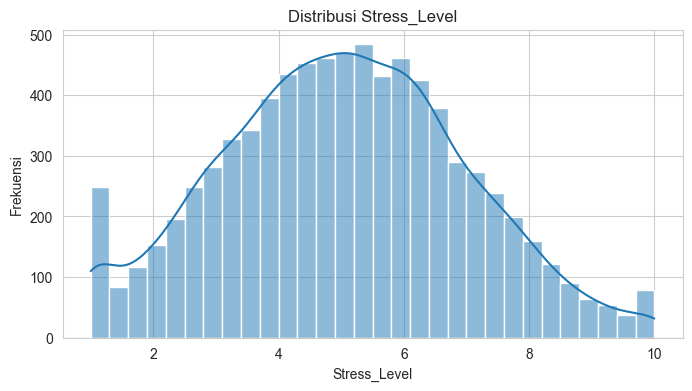

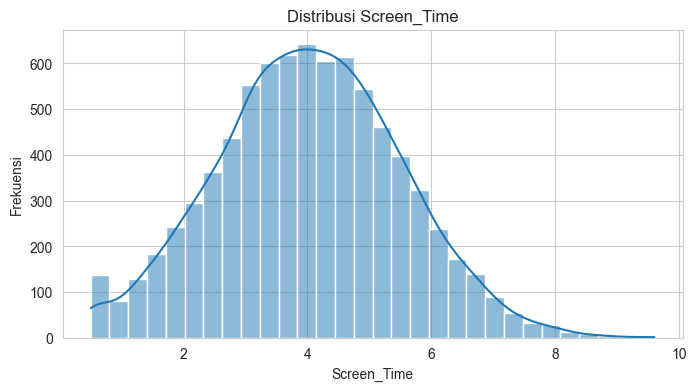

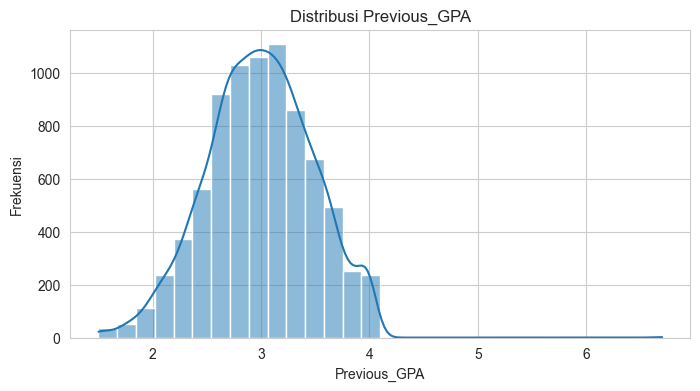

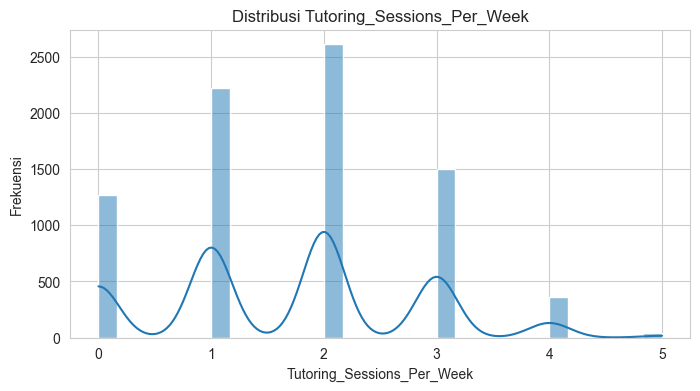

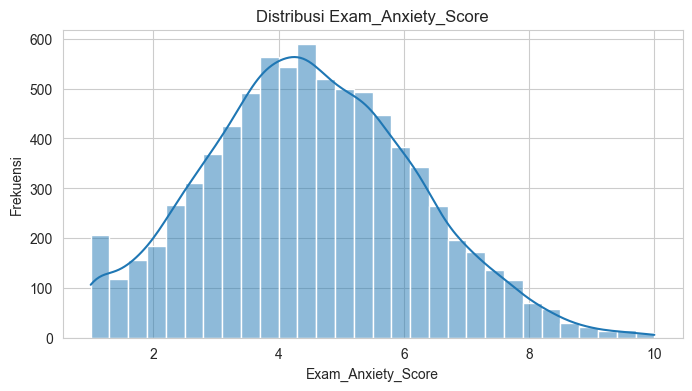

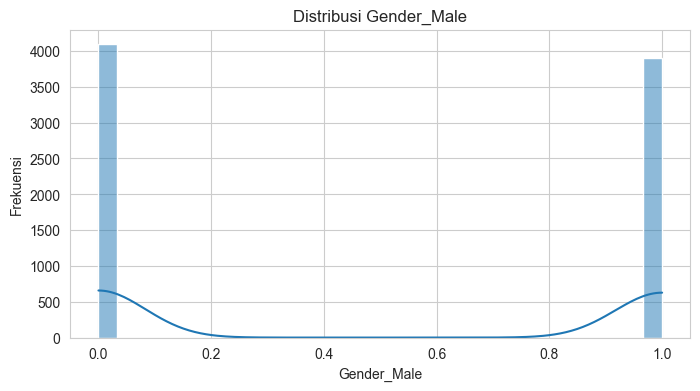

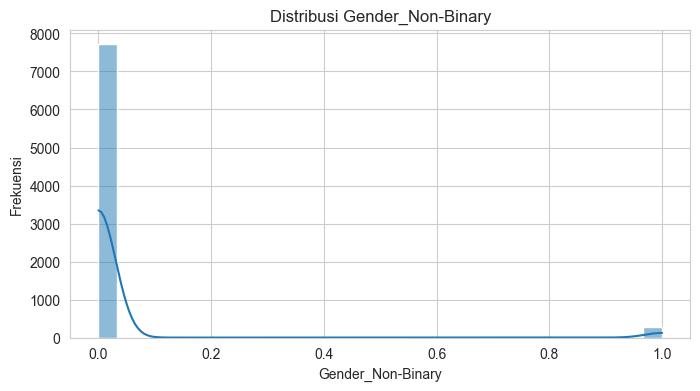

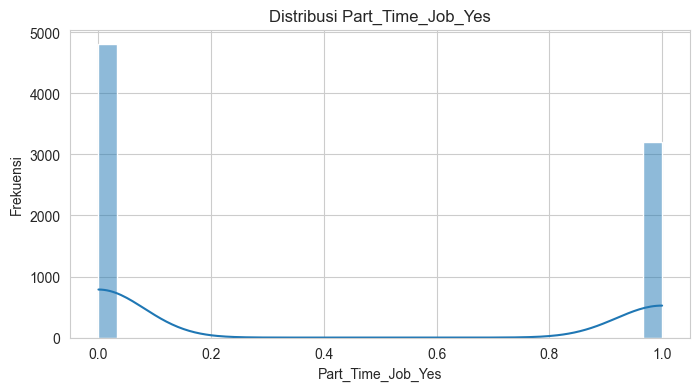

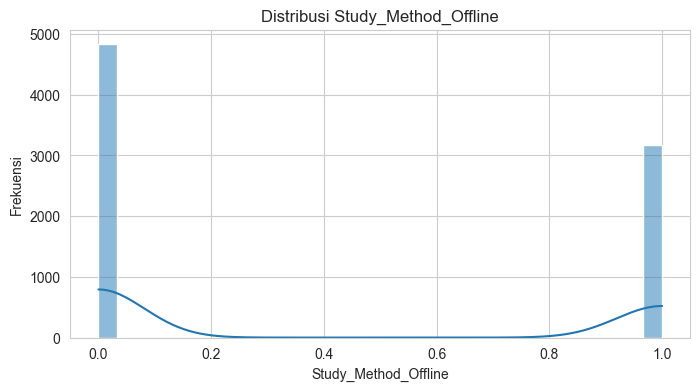

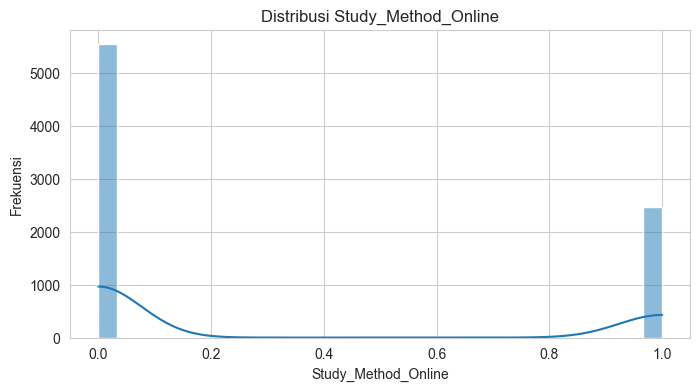

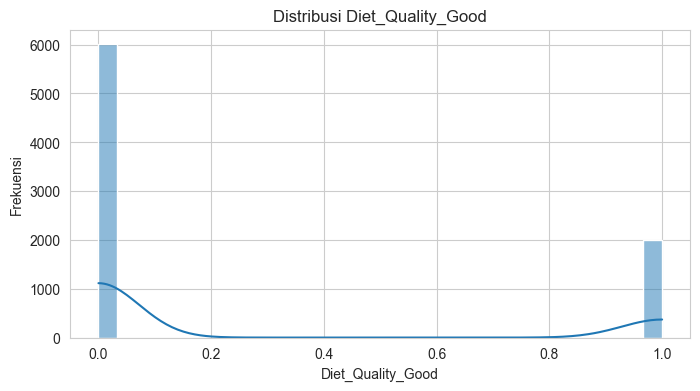

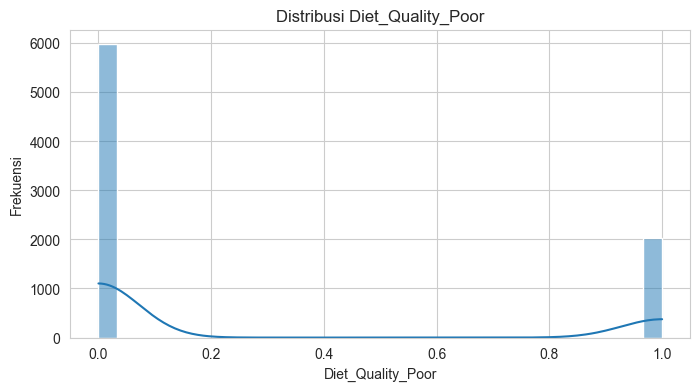

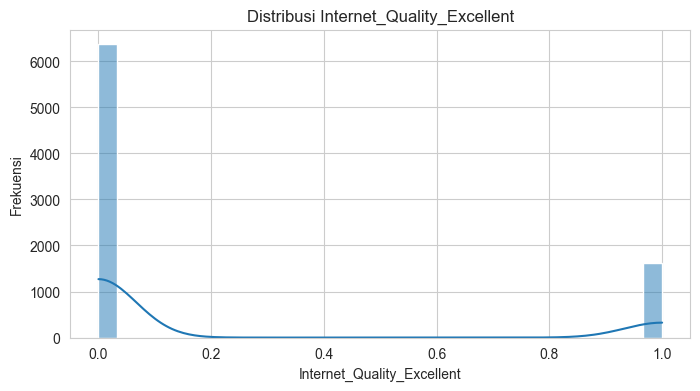

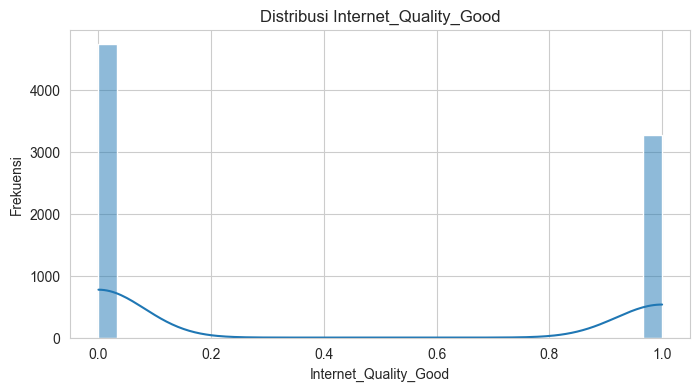

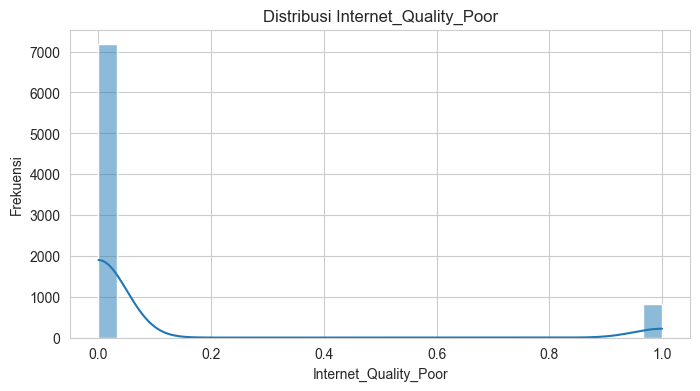

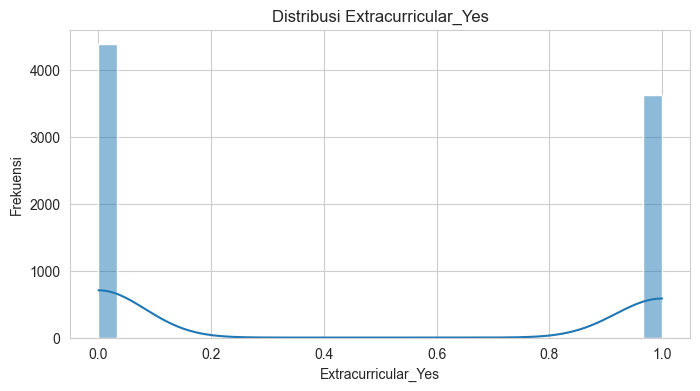

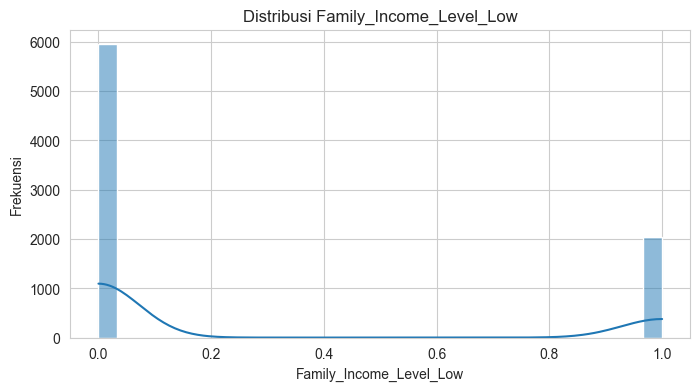

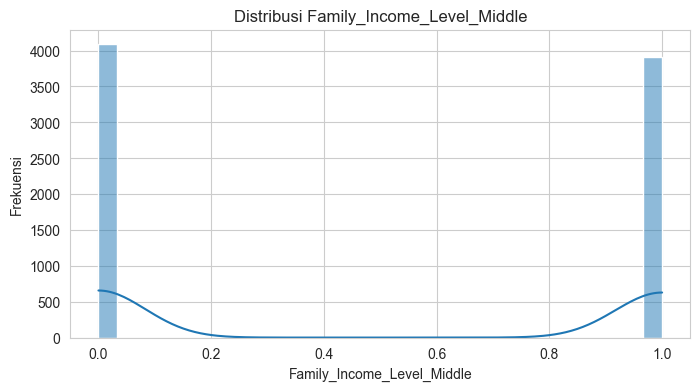

In [20]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_encoded[col], bins=30, kde=True)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

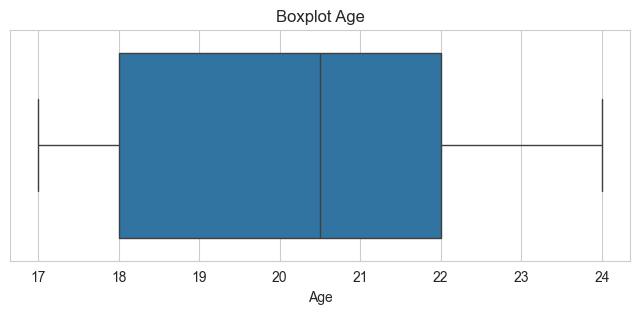

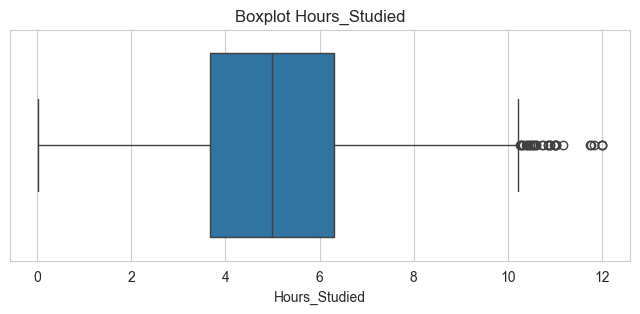

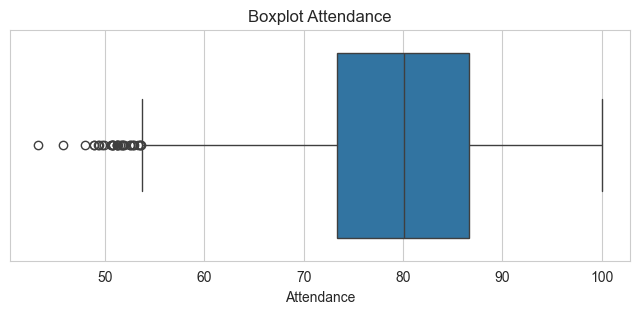

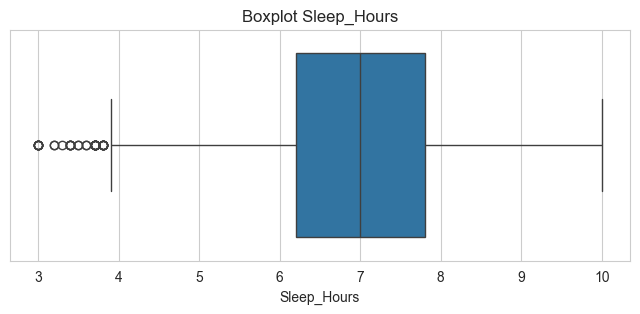

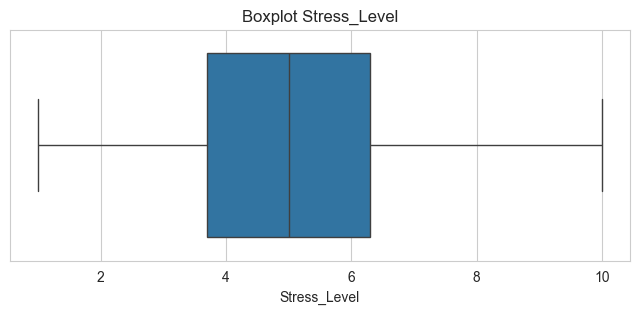

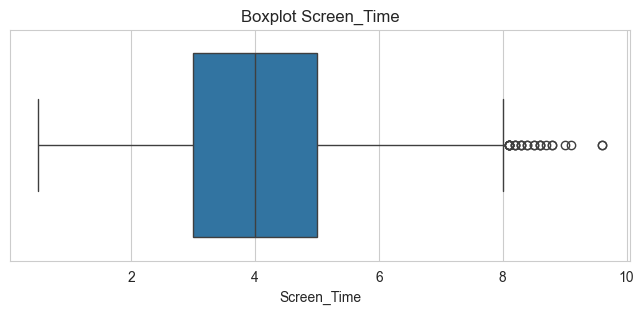

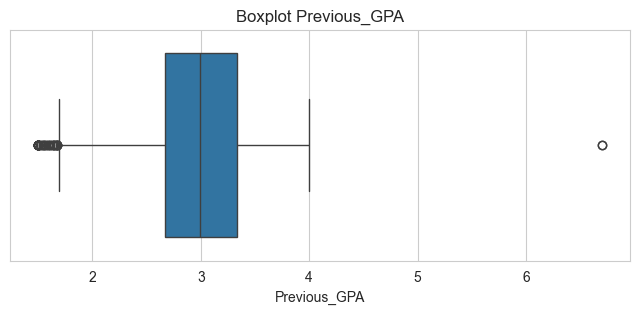

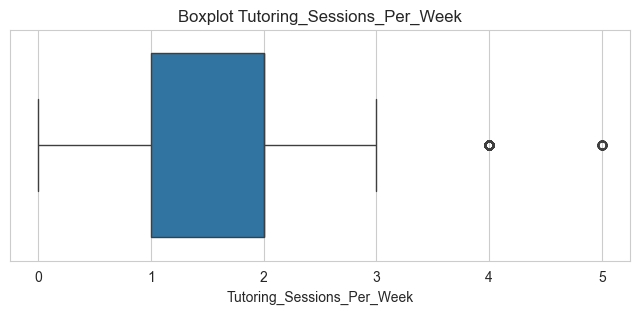

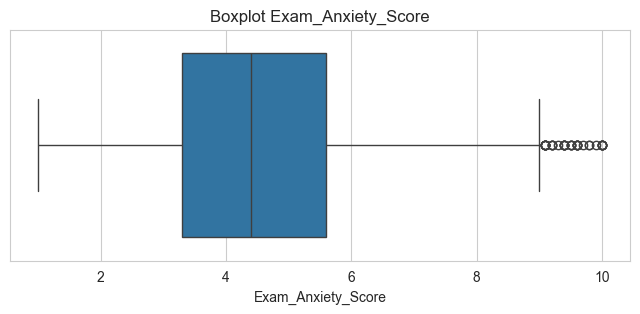

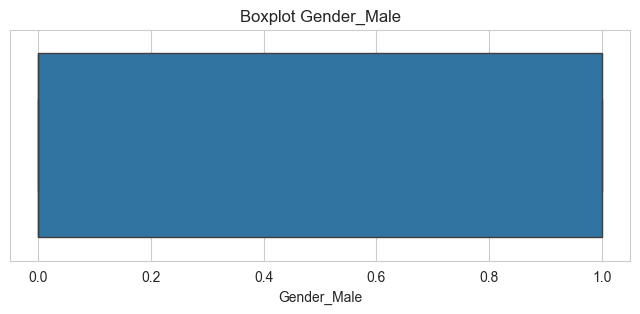

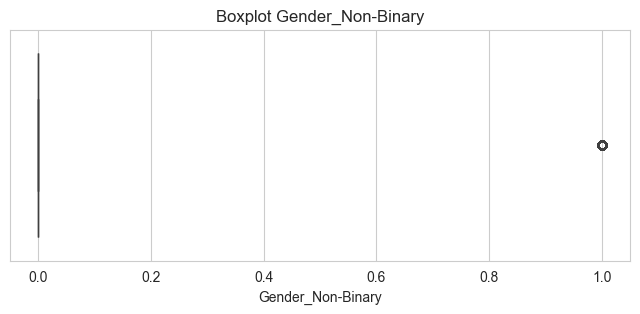

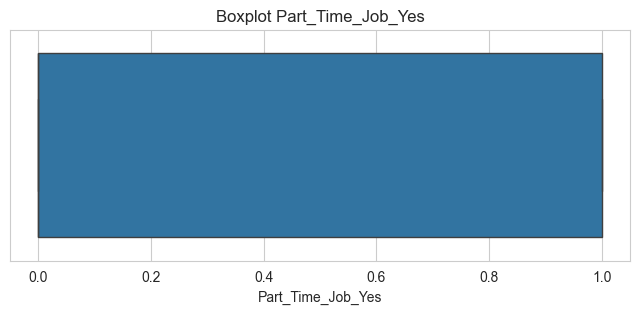

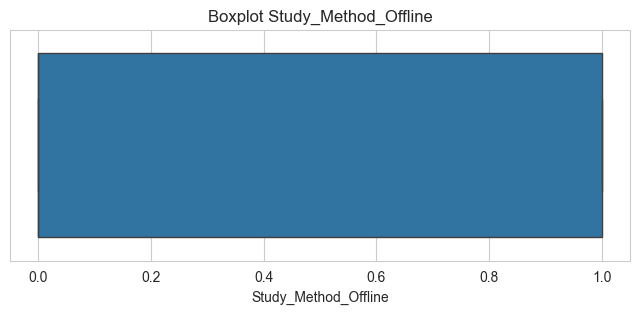

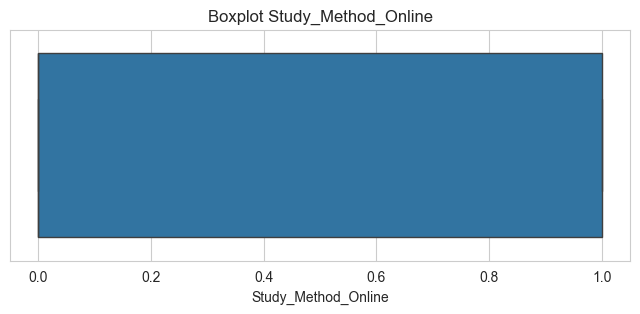

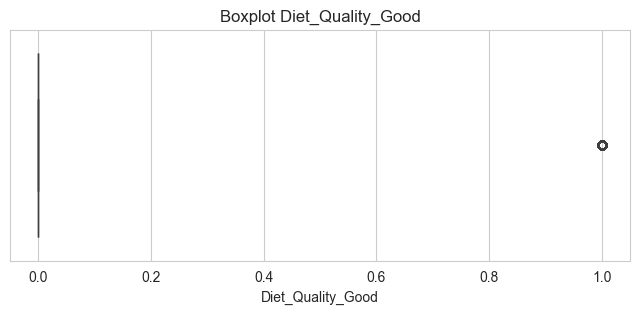

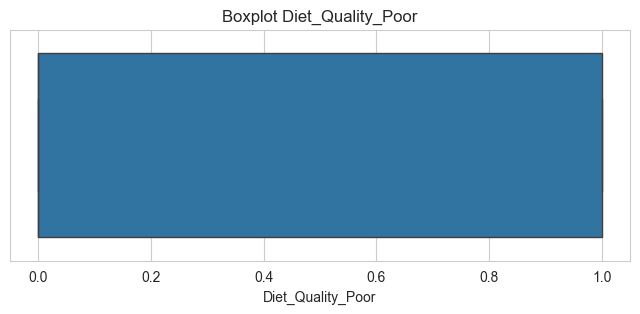

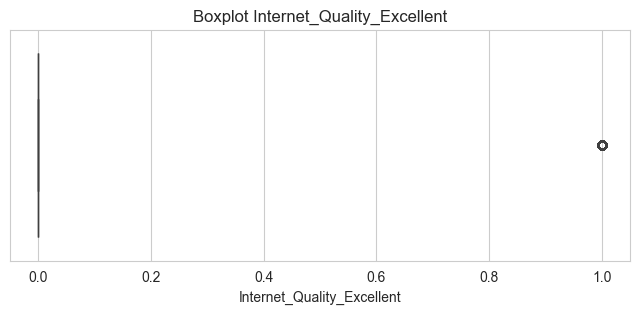

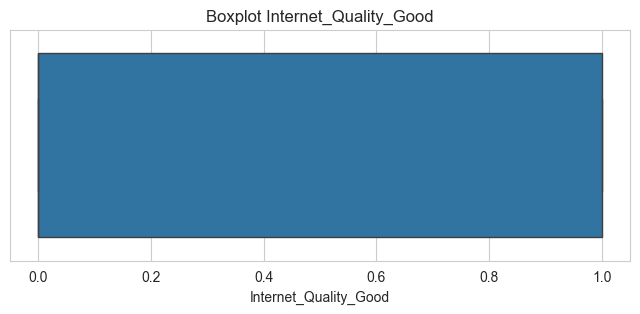

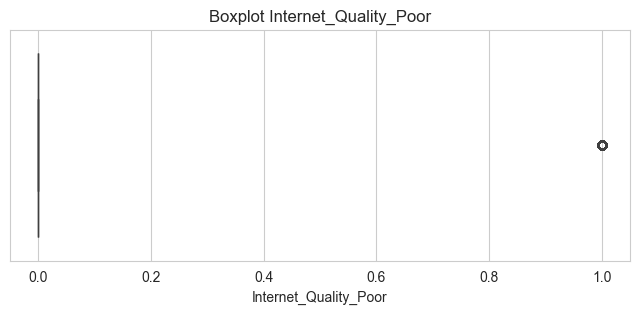

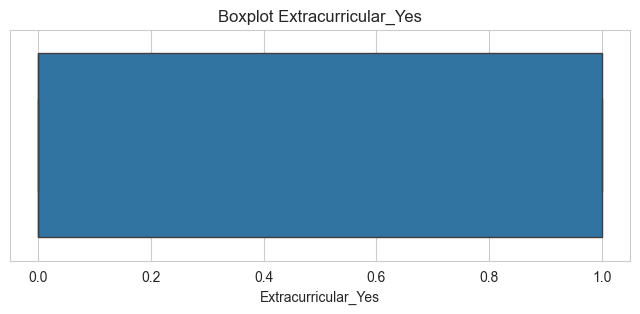

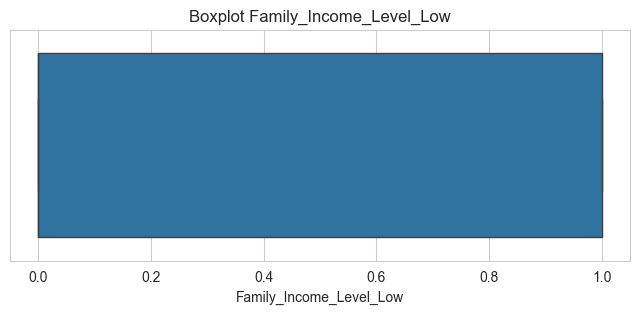

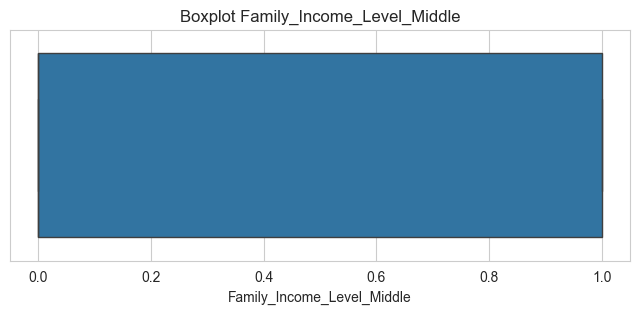

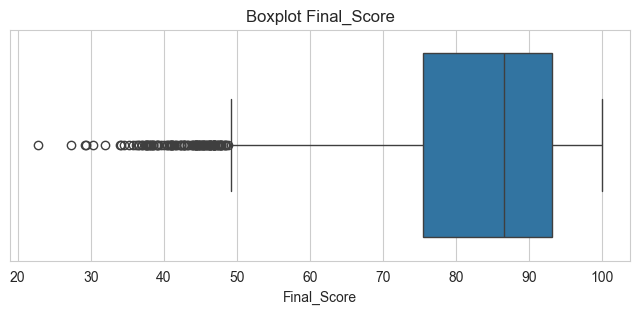

In [21]:
#Boxplot pertama

for col in numerical_cols + ['Final_Score']:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_encoded[col])
    plt.title(f'Boxplot {col}')
    plt.show()

In [22]:
for col in numerical_cols + ['Final_Score']:

    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_encoded[
        (df_encoded[col] < lower_bound) |
        (df_encoded[col] > upper_bound)
    ]

    percentage = (len(outliers) / len(df_encoded)) * 100

    print(f"{col}")
    print(f"Jumlah outlier : {len(outliers)}")
    print(f"Persentase     : {percentage:.2f}%")
    print("-" * 40)

Age
Jumlah outlier : 0
Persentase     : 0.00%
----------------------------------------
Hours_Studied
Jumlah outlier : 31
Persentase     : 0.39%
----------------------------------------
Attendance
Jumlah outlier : 32
Persentase     : 0.40%
----------------------------------------
Sleep_Hours
Jumlah outlier : 40
Persentase     : 0.50%
----------------------------------------
Stress_Level
Jumlah outlier : 0
Persentase     : 0.00%
----------------------------------------
Screen_Time
Jumlah outlier : 27
Persentase     : 0.34%
----------------------------------------
Previous_GPA
Jumlah outlier : 39
Persentase     : 0.49%
----------------------------------------
Tutoring_Sessions_Per_Week
Jumlah outlier : 405
Persentase     : 5.06%
----------------------------------------
Exam_Anxiety_Score
Jumlah outlier : 39
Persentase     : 0.49%
----------------------------------------
Gender_Male
Jumlah outlier : 0
Persentase     : 0.00%
----------------------------------------
Gender_Non-Binary
Jumlah 

In [23]:
df[df['Hours_Studied'] < 0
]

,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score


In [24]:
df[(df['Stress_Level'] < 1) | (df['Stress_Level'] > 10)]

,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score


In [25]:
df[(df['Attendance'] < 0) | (df['Attendance'] > 100)]

,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score


In [26]:
df[df['Tutoring_Sessions_Per_Week'] > 4]

,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score
153,23,Non-Binary,6.39,55.4,6.9,2.7,4.5,3.30,No,Online,Average,Average,No,5,High,1.9,94.83
398,18,Female,8.08,72.7,7.3,4.8,3.6,3.96,Yes,Online,Poor,Excellent,No,5,Middle,1.8,98.53
515,21,Female,4.50,74.2,6.4,4.9,3.6,2.44,Yes,Offline,Good,Good,No,5,Middle,2.5,90.00
842,24,Male,6.32,78.7,7.0,2.1,2.4,2.99,Yes,Online,Poor,Good,Yes,5,Low,4.4,95.55
1446,19,Male,8.26,81.0,7.6,1.0,5.1,3.39,No,Hybrid,Poor,Average,No,5,Low,1.2,96.24
1760,20,Female,7.61,83.1,7.4,4.0,7.2,2.79,Yes,Hybrid,Average,Good,No,5,High,3.6,99.45
1785,20,Female,8.70,87.7,8.8,5.3,4.9,2.11,Yes,Online,Good,Excellent,Yes,5,Middle,3.9,98.28
1845,24,Female,4.75,73.7,7.7,5.0,1.4,4.00,Yes,Online,Poor,Good,No,5,High,2.8,98.94
1985,20,Female,2.03,83.9,7.7,5.7,3.2,2.85,No,Hybrid,Good,Excellent,No,5,Middle,5.7,90.61
2021,23,Male,5.26,74.7,6.0,3.6,4.7,2.77,No,Offline,Average,Average,Yes,5,High,2.4,93.47


In [27]:
df[df['Screen_Time'] > 10]

,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score


In [28]:
df[df['Previous_GPA'] > 4]

,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score
3127,21,Male,4.71,81.8,5.7,3.1,3.4,6.7,Yes,Hybrid,Average,Average,No,3,Middle,4.9,94.11
3203,23,Male,4.10,72.6,7.1,4.8,4.6,6.7,No,Online,Poor,Average,Yes,2,Middle,4.4,67.44


In [29]:
df[df['Final_Score'] < 50 ]

,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score
7,19,Male,1.49,77.4,6.0,6.2,4.7,2.08,No,Offline,Average,Average,Yes,0,Middle,7.1,44.64
34,18,Male,0.87,71.1,6.5,8.0,5.2,2.63,No,Hybrid,Average,Good,No,0,Middle,6.8,45.31
79,20,Female,1.44,75.3,7.8,7.5,5.1,1.94,No,Online,Poor,Poor,Yes,0,Middle,9.6,40.92
103,24,Male,2.11,89.3,7.5,8.4,3.4,2.26,No,Offline,Poor,Excellent,Yes,0,Middle,5.5,36.58
196,20,Male,1.18,100.0,9.2,6.3,3.4,2.19,No,Online,Poor,Average,Yes,0,Low,6.8,46.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7370,22,Female,5.04,76.1,4.6,9.3,4.6,2.70,No,Offline,Poor,Average,Yes,0,Middle,6.7,44.38
7458,18,Male,0.55,75.4,8.0,9.3,4.5,3.63,No,Offline,Poor,Good,Yes,2,Middle,5.8,47.62
7504,17,Male,0.83,88.1,7.6,9.1,1.7,2.33,No,Hybrid,Poor,Good,No,0,Middle,9.5,42.12
7852,22,Non-Binary,0.86,84.4,5.8,5.9,6.5,2.78,No,Offline,Average,Average,Yes,1,High,8.4,42.31


In [30]:
corr_matrix = df_encoded.corr(numeric_only=True)

print('=' * 60)
print('CORRELATION MATRIX')
print('=' * 60)
display(corr_matrix.round(3))

CORRELATION MATRIX


,Age,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Tutoring_Sessions_Per_Week,Exam_Anxiety_Score,Final_Score,Gender_Male,Gender_Non-Binary,Part_Time_Job_Yes,Study_Method_Offline,Study_Method_Online,Diet_Quality_Good,Diet_Quality_Poor,Internet_Quality_Excellent,Internet_Quality_Good,Internet_Quality_Poor,Extracurricular_Yes,Family_Income_Level_Low,Family_Income_Level_Middle
Age,1.000,-0.001,-0.000,-0.005,-0.011,0.003,0.013,0.005,-0.010,0.017,0.002,0.009,0.027,0.019,-0.002,-0.004,-0.006,-0.005,-0.016,0.005,0.007,0.000,0.003
Hours_Studied,-0.001,1.000,0.017,0.020,-0.011,0.000,0.012,0.267,-0.286,0.591,-0.001,-0.008,-0.010,-0.016,0.010,-0.012,0.001,0.011,-0.005,-0.001,0.004,0.011,-0.002
Attendance,-0.000,0.017,1.000,0.004,-0.008,0.003,0.011,0.061,-0.090,0.169,0.002,-0.032,0.017,0.012,0.015,-0.010,0.002,0.005,0.019,-0.022,-0.013,-0.012,-0.003
Sleep_Hours,-0.005,0.020,0.004,1.000,0.032,-0.011,0.004,0.072,-0.085,0.152,-0.011,-0.020,0.005,0.000,0.022,0.000,0.024,0.027,-0.016,-0.010,-0.009,0.012,-0.001
Stress_Level,-0.011,-0.011,-0.008,0.032,1.000,0.001,-0.001,-0.170,0.158,-0.297,-0.001,-0.011,-0.025,0.005,-0.000,0.004,-0.003,0.017,0.008,-0.001,-0.004,0.007,0.013
Screen_Time,0.003,0.000,0.003,-0.011,0.001,1.000,0.008,-0.051,0.070,-0.135,-0.001,-0.004,-0.008,0.003,0.006,0.007,0.008,0.014,-0.000,-0.004,0.026,0.003,0.007
Previous_GPA,0.013,0.012,0.011,0.004,-0.001,0.008,1.000,0.139,-0.156,0.291,0.010,0.003,0.015,0.018,-0.005,-0.020,0.011,-0.007,-0.002,-0.005,0.004,0.001,-0.007
Tutoring_Sessions_Per_Week,0.005,0.267,0.061,0.072,-0.170,-0.051,0.139,1.000,-0.235,0.472,0.026,-0.012,-0.029,-0.013,-0.005,0.062,-0.051,-0.006,0.004,0.009,0.024,0.015,-0.005
Exam_Anxiety_Score,-0.010,-0.286,-0.090,-0.085,0.158,0.070,-0.156,-0.235,1.000,-0.495,-0.006,0.011,0.025,0.027,-0.007,-0.059,0.056,0.001,0.006,0.006,-0.013,0.006,0.007
Final_Score,0.017,0.591,0.169,0.152,-0.297,-0.135,0.291,0.472,-0.495,1.000,0.002,-0.011,-0.066,-0.012,-0.019,0.095,-0.102,0.004,-0.008,0.005,-0.002,0.008,-0.006


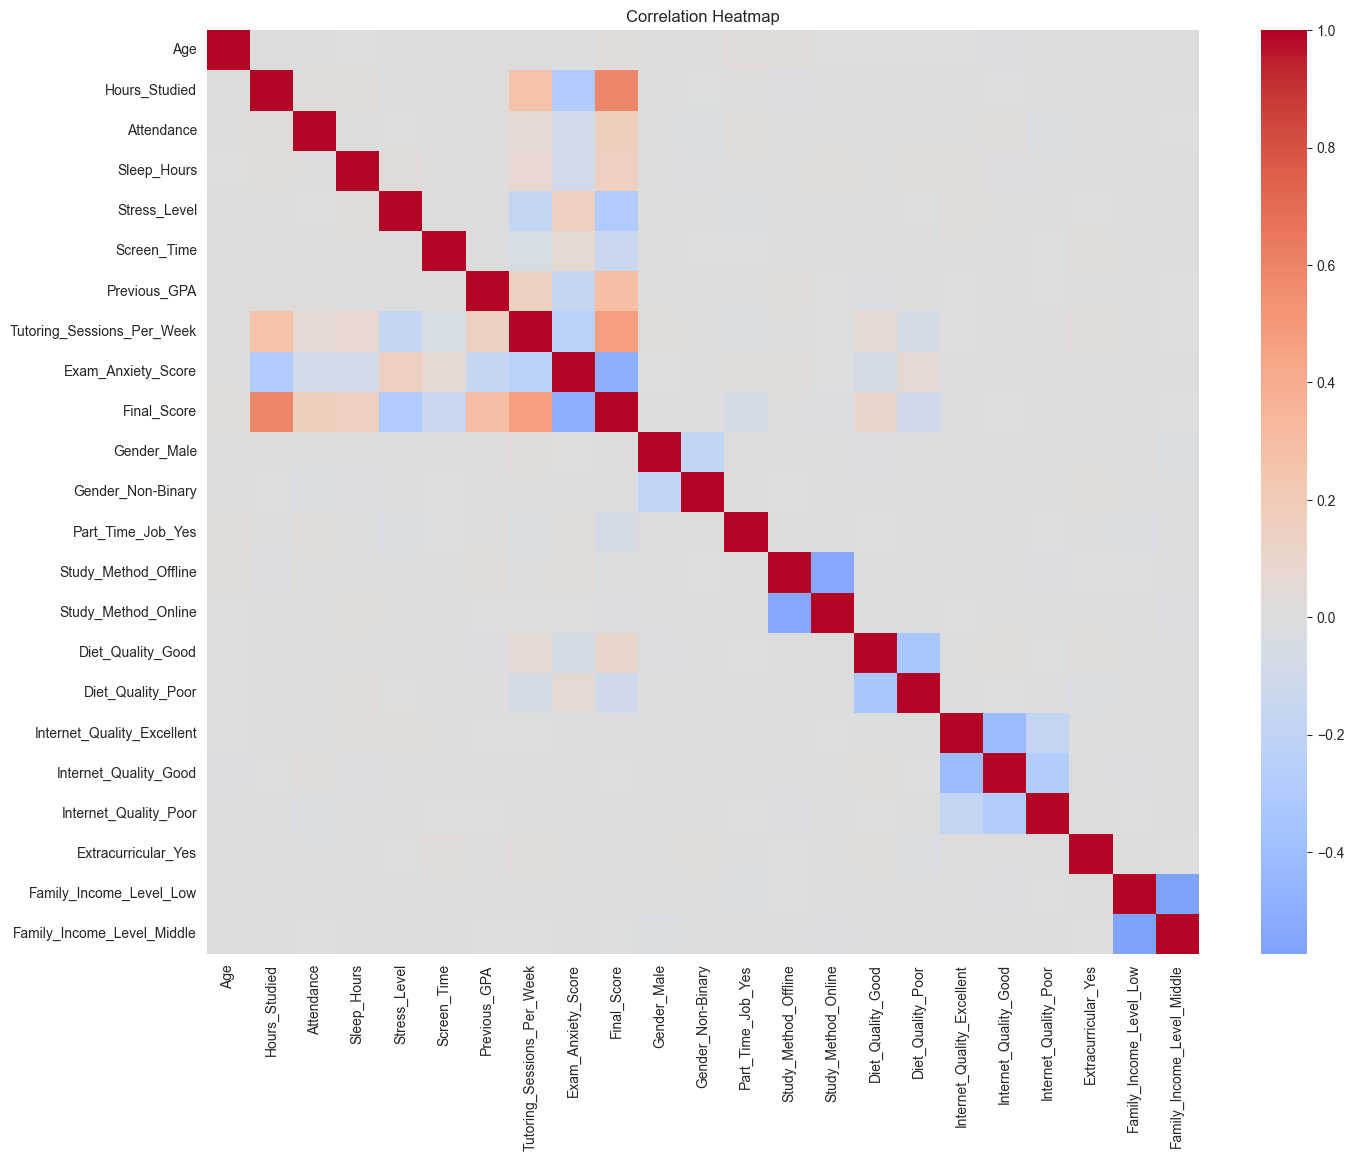

In [31]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [32]:
target_corr = corr_matrix['Final_Score'].drop('Final_Score')
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)

print('=' * 60)
print('KORELASI FITUR TERHADAP FINAL SCORE')
display(target_corr.to_frame('Correlation'))

KORELASI FITUR TERHADAP FINAL SCORE


,Correlation
Hours_Studied,0.591355
Exam_Anxiety_Score,-0.494940
Tutoring_Sessions_Per_Week,0.471524
Stress_Level,-0.296634
Previous_GPA,0.291002
Attendance,0.168615
Sleep_Hours,0.151673
Screen_Time,-0.135252
Diet_Quality_Poor,-0.101529
Diet_Quality_Good,0.094924


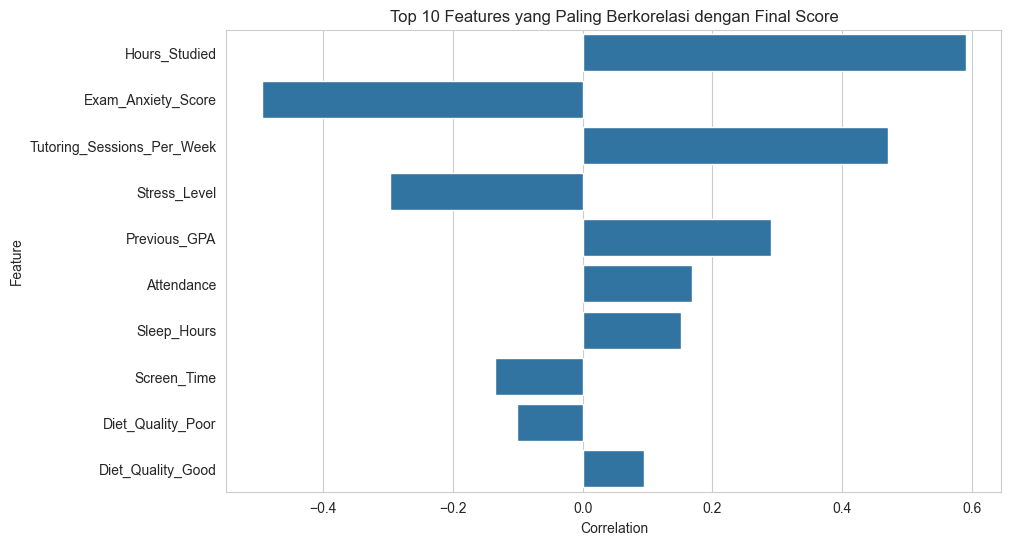

In [33]:
top_features = target_corr.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title('Top 10 Features yang Paling Berkorelasi dengan Final Score')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.show()

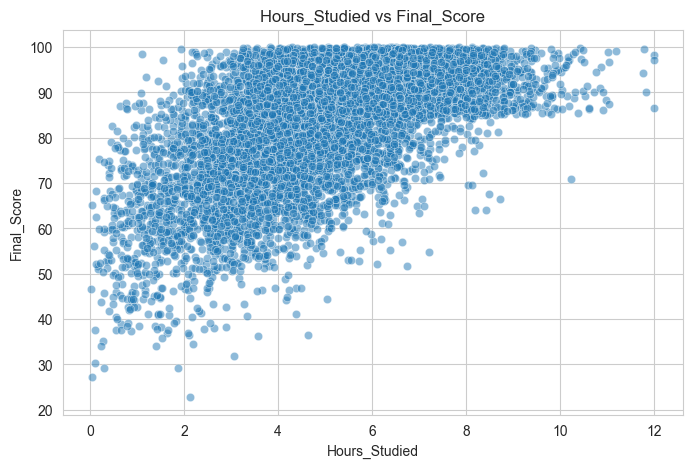

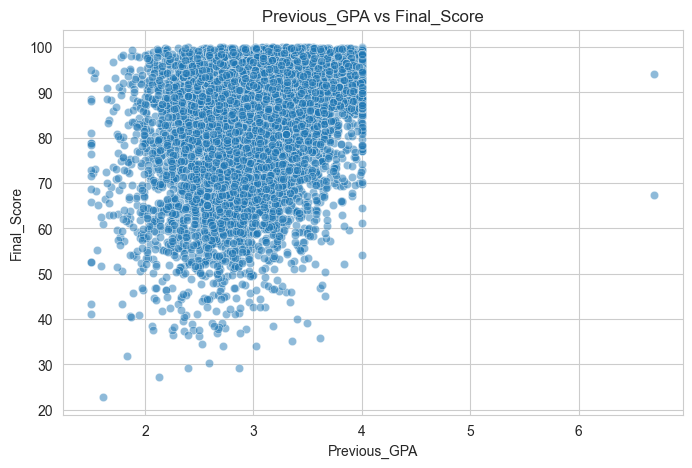

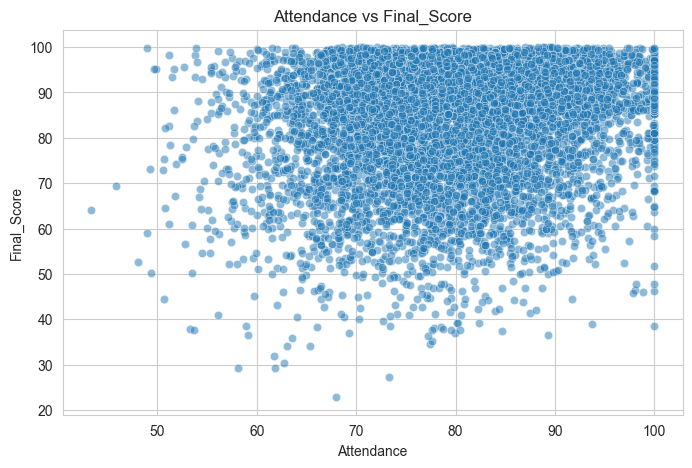

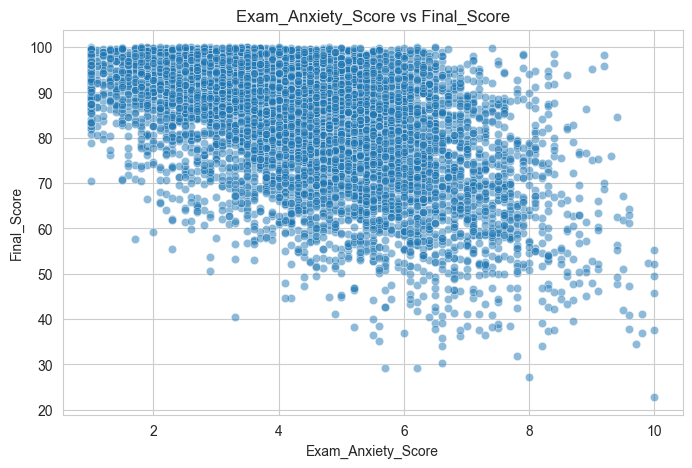

In [34]:
important_features = [
    'Hours_Studied',
    'Previous_GPA',
    'Attendance',
    'Exam_Anxiety_Score'
]

for feature in important_features:
    if feature in df_encoded.columns:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df_encoded, x=feature, y='Final_Score', alpha=0.5)
        plt.title(f'{feature} vs Final_Score')
        plt.show()

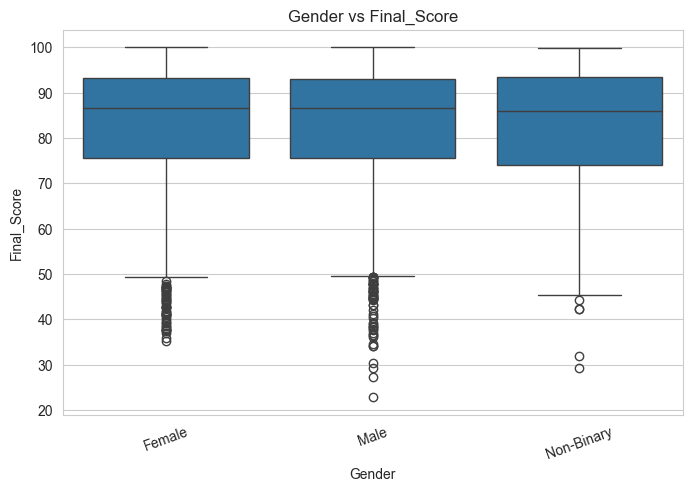

\nSummary for Gender


,mean,median,count
Gender,,,
Female,83.229362,86.55,3810
Male,83.237284,86.50,3906
Non-Binary,82.452430,85.96,284


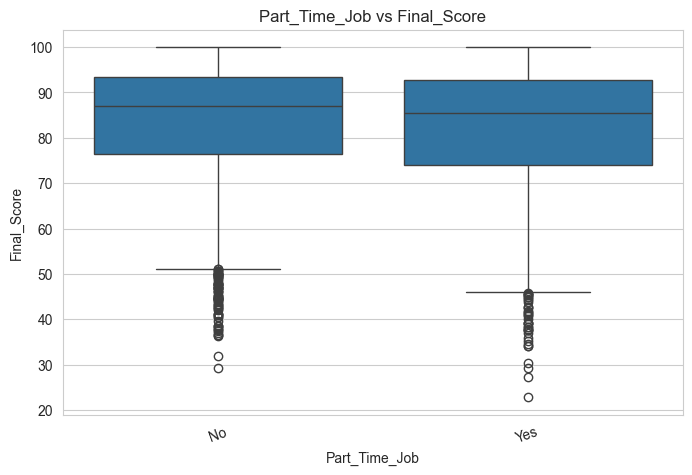

\nSummary for Part_Time_Job


,mean,median,count
Part_Time_Job,,,
No,83.889592,87.10,4803
Yes,82.178129,85.55,3197


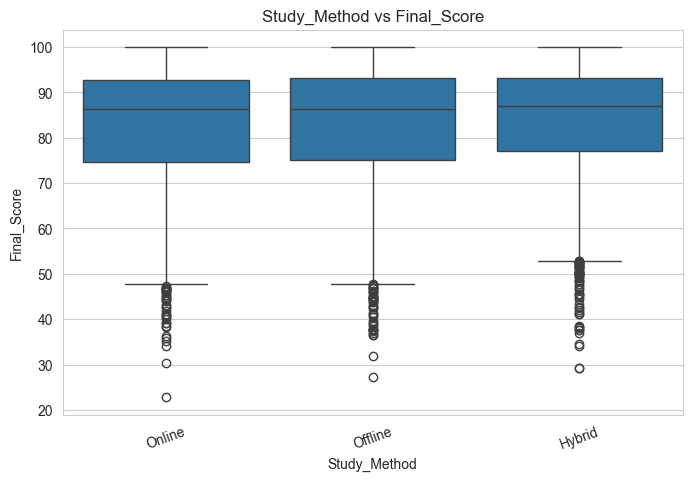

\nSummary for Study_Method


,mean,median,count
Study_Method,,,
Hybrid,83.819148,87.08,2370
Offline,83.022609,86.35,3170
Online,82.850463,86.31,2460


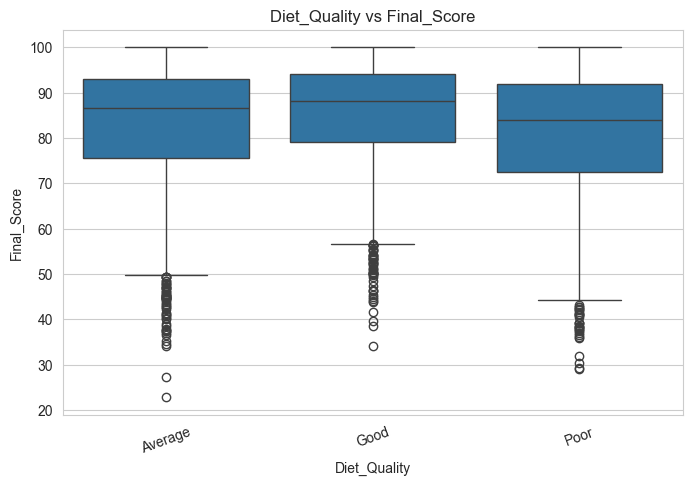

\nSummary for Diet_Quality


,mean,median,count
Diet_Quality,,,
Average,83.284879,86.620,3980
Good,85.307096,88.120,1994
Poor,80.981747,83.855,2026


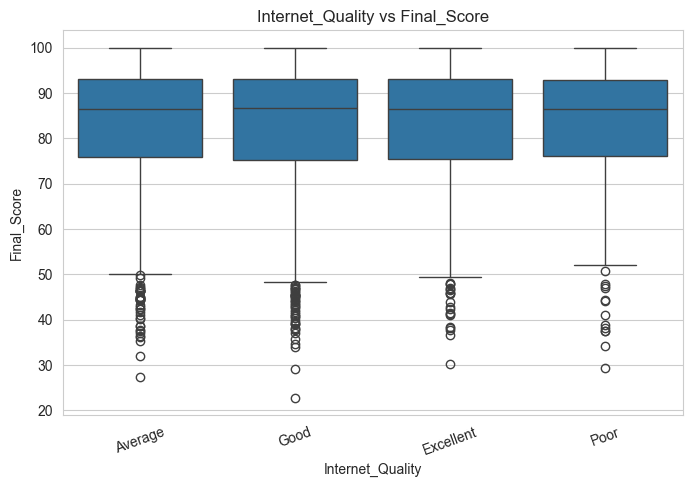

\nSummary for Internet_Quality


,mean,median,count
Internet_Quality,,,
Average,83.236613,86.500,2285
Excellent,83.310196,86.470,1629
Good,83.081733,86.590,3266
Poor,83.405220,86.435,820


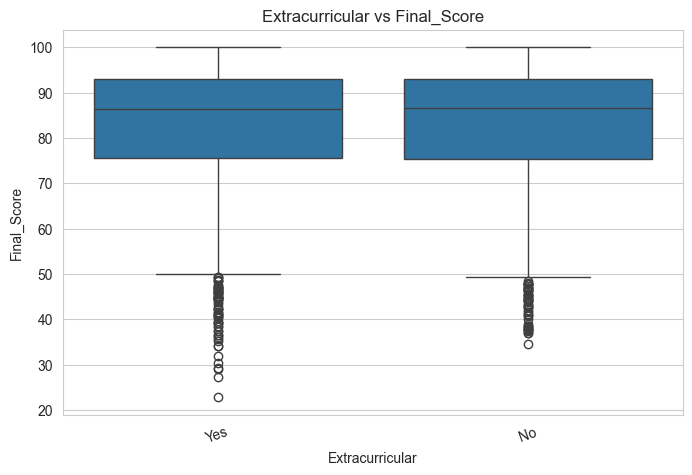

\nSummary for Extracurricular


,mean,median,count
Extracurricular,,,
No,83.228551,86.58,4381
Yes,83.177925,86.42,3619


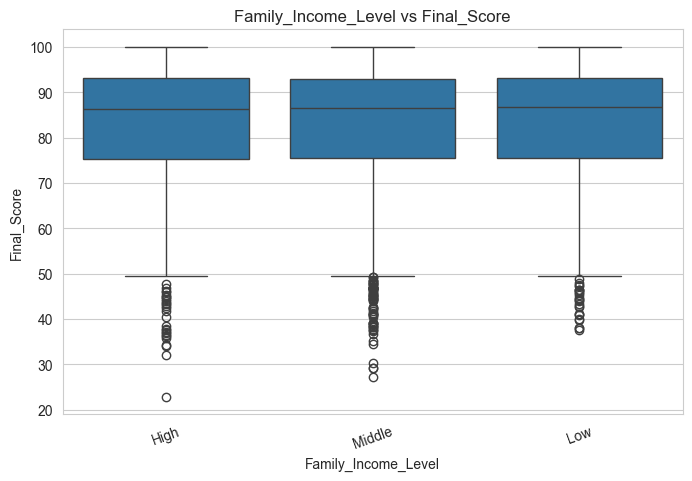

\nSummary for Family_Income_Level


,mean,median,count
Family_Income_Level,,,
High,83.165387,86.365,2040
Low,83.390049,86.755,2048
Middle,83.130107,86.490,3912


In [35]:
categorical_features_for_eda = [
    'Gender',
    'Part_Time_Job',
    'Study_Method',
    'Diet_Quality',
    'Internet_Quality',
    'Extracurricular',
    'Family_Income_Level'
]

for feature in categorical_features_for_eda:
    if feature in df.columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=df, x=feature, y='Final_Score')
        plt.title(f'{feature} vs Final_Score')
        plt.xticks(rotation=20)                         
        plt.show()

        summary = df.groupby(feature)['Final_Score'].agg(['mean', 'median', 'count'])
        print(f'\\nSummary for {feature}')
        display(summary)

In [36]:
print('=' * 60)
print('INSIGHT SUMMARY')
print('=' * 60)

print('Top 5 fitur dengan korelasi absolut tertinggi terhadap Final_Score:')
display(target_corr.abs().sort_values(ascending=False).head(5))

print('\\nInterpretasi umum:')
print('- Korelasi positif berarti semakin tinggi fitur tersebut, semakin tinggi Final_Score.')
print('- Korelasi negatif berarti semakin tinggi fitur tersebut, semakin rendah Final_Score.')
print('- Previous_GPA dan Hours_Studied biasanya menjadi prediktor terkuat.')

INSIGHT SUMMARY
Top 5 fitur dengan korelasi absolut tertinggi terhadap Final_Score:


Hours_Studied                 0.591355
Exam_Anxiety_Score            0.494940
Tutoring_Sessions_Per_Week    0.471524
Stress_Level                  0.296634
Previous_GPA                  0.291002
Name: Final_Score, dtype: float64

\nInterpretasi umum:
- Korelasi positif berarti semakin tinggi fitur tersebut, semakin tinggi Final_Score.
- Korelasi negatif berarti semakin tinggi fitur tersebut, semakin rendah Final_Score.
- Previous_GPA dan Hours_Studied biasanya menjadi prediktor terkuat.


### MODELS

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [97]:
df_fe = df_encoded.copy()

In [99]:
df_fe["Study_Efficiency"] = (
    df_fe["Hours_Studied"] / (df_fe["Stress_Level"] + 1)
)

df_fe["Sleep_Study_Balance"] = (
    df_fe["Sleep_Hours"] * df_fe["Hours_Studied"]
)

df_fe["Anxiety_Attendance"] = (
    df_fe["Exam_Anxiety_Score"] * df_fe["Attendance"]
)

df_fe["Academic_Consistency"] = (
    df_fe["Previous_GPA"] / df_fe["Attendance"]
)

df_fe["Productivity_Score"] = (
    df_fe["Hours_Studied"] + df_fe["Attendance"]/10 + df_fe["Sleep_Hours"]
)

df_fe["Stress_per_Study_Hour"] = (
    df_fe["Stress_Level"] / (df_fe["Hours_Studied"] + 1)
)

In [100]:
X = df_fe.drop("Final_Score", axis=1)
y = df_fe["Final_Score"]

In [86]:
print(X.columns)

Index(['Age', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Stress_Level',
       'Screen_Time', 'Previous_GPA', 'Tutoring_Sessions_Per_Week',
       'Exam_Anxiety_Score', 'Gender_Male', 'Gender_Non-Binary',
       'Part_Time_Job_Yes', 'Study_Method_Offline', 'Study_Method_Online',
       'Diet_Quality_Good', 'Diet_Quality_Poor', 'Internet_Quality_Excellent',
       'Internet_Quality_Good', 'Internet_Quality_Poor', 'Extracurricular_Yes',
       'Family_Income_Level_Low', 'Family_Income_Level_Middle'],
      dtype='object')


In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)


In [44]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Absolute Error: 5.278070747216245
Mean Squared Error: 45.1252052699172
R² Score: 0.7264006120665675


In [45]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

In [46]:
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [47]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# Print results
print("Gradient Boosting Results")
print("Mean Absolute Error:", mae_gb)
print("Mean Squared Error:", mse_gb)
print("R² Score:", r2_gb)

Gradient Boosting Results
Mean Absolute Error: 5.054323821235401
Mean Squared Error: 42.13745484469447
R² Score: 0.7445156917154958


In [63]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor(random_state=42)

In [64]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [65]:
print(grid_search.best_score_)

0.7343795435433048


### Final Working XGBoost Model (so far...)

In [102]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [103]:
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [104]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("MAE:", mae_xgb)
print("MSE:", mse_xgb)
print("R² Score:", r2_xgb)

XGBoost Results
MAE: 4.980309016132355
MSE: 40.923551332337205
R² Score: 0.7518757304345353


In [50]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

In [51]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [52]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R² Score:", r2_rf)

Random Forest Results
MAE: 5.268048226968051
MSE: 45.35564408939406
R² Score: 0.7250034346002745


In [53]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "MSE": [mse, mse_rf],
    "R² Score": [r2, r2_rf]
})

print(comparison)

               Model       MAE        MSE  R² Score
0  Linear Regression  5.278071  45.125205  0.726401
1      Random Forest  5.268048  45.355644  0.725003


In [69]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                       Feature  Importance
22            Study_Efficiency    0.338314
7   Tutoring_Sessions_Per_Week    0.113323
27       Stress_per_Study_Hour    0.103341
26          Productivity_Score    0.099301
8           Exam_Anxiety_Score    0.067517
6                 Previous_GPA    0.059888
15           Diet_Quality_Poor    0.027473
14           Diet_Quality_Good    0.024805
5                  Screen_Time    0.021178
11           Part_Time_Job_Yes    0.015739
4                 Stress_Level    0.015287
23         Sleep_Study_Balance    0.014302
2                   Attendance    0.011064
24          Anxiety_Attendance    0.010971
25        Academic_Consistency    0.008381
1                Hours_Studied    0.007982
20     Family_Income_Level_Low    0.006496
9                  Gender_Male    0.006180
18       Internet_Quality_Poor    0.006092
13         Study_Method_Online    0.005885
3                  Sleep_Hours    0.005727
12        Study_Method_Offline    0.005469
19         

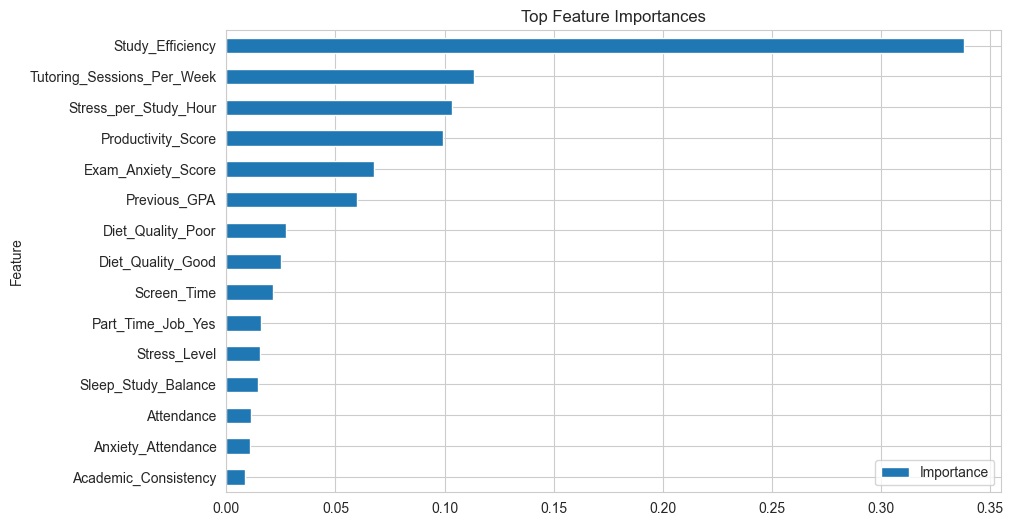

In [70]:
import matplotlib.pyplot as plt 

feature_importance.head(15).plot(
    kind='barh',
    x='Feature',
    y='Importance',
    figsize=(10,6)
)

plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.show()

In [57]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "R² Score": [
        r2,
        r2_rf,
        r2_gb,
        r2_xgb
    ]
})

print(comparison)

               Model  R² Score
0  Linear Regression  0.726401
1      Random Forest  0.725003
2  Gradient Boosting  0.744516
3            XGBoost  0.751876


### Feature Selection

In [76]:
low_importance_features = feature_importance[
    feature_importance['Importance'] < 0.007
]['Feature']

print(low_importance_features)

20       Family_Income_Level_Low
9                    Gender_Male
18         Internet_Quality_Poor
13           Study_Method_Online
3                    Sleep_Hours
12          Study_Method_Offline
19           Extracurricular_Yes
17         Internet_Quality_Good
10             Gender_Non-Binary
16    Internet_Quality_Excellent
21    Family_Income_Level_Middle
0                            Age
Name: Feature, dtype: object


In [77]:
X_selected = X.drop(columns=low_importance_features)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [105]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [106]:
y_pred = xgb_model.predict(X_test)

r2_new = r2_score(y_test, y_pred)

print("New R²:", r2_new)

New R²: 0.7518757304345353


## Saving the Model

In [107]:
import pickle

with open("best_xgboost_model.pkl", "wb") as file:
    pickle.dump(xgb_model, file)

print("Model Saved Successfully!")

Model Saved Successfully!


In [108]:
with open("model_features.pkl", "wb") as file:
    pickle.dump(X.columns.tolist(), file)

print("Feature Columns Saved Successfully!")

Feature Columns Saved Successfully!
